## **Handling Outliers using Z-Score**

### Topic Roadmap

**1. Imports and Dataset Loading**

**2. Data Visualization (Distribution Check)**

**3. Calculating Boundaries (3 Standard Deviations)**

**4. Detecting Outliers**

**5. Strategy 1: Trimming**

**6. Strategy 2: Capping (Winsorization)**

**7. Key Revision Notes**

### **1. Imports and Dataset Loading**

Import standard libraries and load the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\bmh.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


In [ ]:
# Load dataset
df = pd.read_csv('docs/Lecture-028-placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


### **2. Data Visualization (Distribution Check)**

The Z-score method is highly effective for normally distributed data. Visualize the feature distributions to confirm normality before applying Z-scores

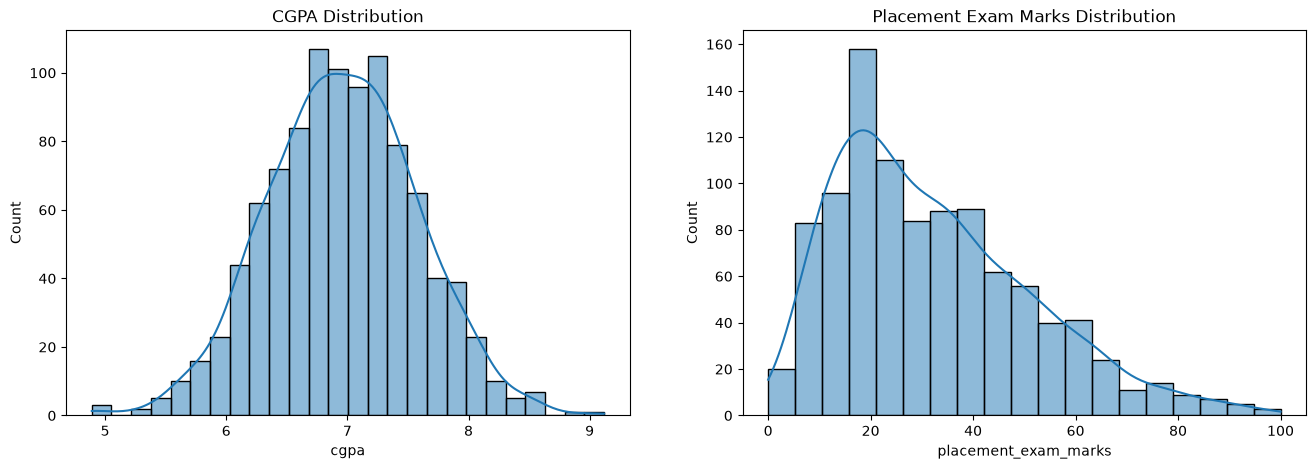

In [3]:
# Plot distributions to check for normality
plt.figure(figsize=(16, 5))

# Normally distributed feature
plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)
plt.title('CGPA Distribution')

# Skewed feature (Better handled via IQR, not Z-score)
plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Placement Exam Marks Distribution')

plt.show()

### **3. Calculating Boundaries (3 Standard Deviations)**

In a normal distribution, ~99.7% of the data lies within 3 standard deviations of the mean. Values outside this range are considered outliers

In [4]:
# Calculate boundary limits
upper_limit = df['cgpa'].mean() + 3 * df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3 * df['cgpa'].std()

print("Highest allowed CGPA:", upper_limit)
print("Lowest allowed CGPA:", lower_limit)

Highest allowed CGPA: 8.808933625397168
Lowest allowed CGPA: 5.113546374602832


### **4. Detecting Outliers**

Filter the dataframe to isolate rows that fall outside the calculated boundaries

In [5]:
# Identify outliers in the dataset
outliers = df[(df['cgpa'] > upper_limit) | (df['cgpa'] < lower_limit)]
outliers

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


### **5. Strategy 1: Trimming**

Trimming involves completely removing outlier rows from the dataset. Create a new dataframe using explicit copy to avoid modifying the original data

In [6]:
# Create explicit Z-score column for trimming
df_trimmed = df.copy()
df_trimmed['cgpa_zscore'] = (df_trimmed['cgpa'] - df_trimmed['cgpa'].mean()) / df_trimmed['cgpa'].std()

In [7]:
# Filter out rows where Z-score is beyond +3 or -3
df_trimmed = df_trimmed[(df_trimmed['cgpa_zscore'] < 3) & (df_trimmed['cgpa_zscore'] > -3)]

print("Original shape:", df.shape)
print("Trimmed shape:", df_trimmed.shape)

Original shape: (1000, 3)
Trimmed shape: (995, 4)


### **6. Strategy 2: Capping (Winsorization)**

Capping replaces outlier values with the exact maximum and minimum limit values, preserving the dataset's row count

In [8]:
# Create a copy for capping
df_capped = df.copy()

In [9]:
# Apply nested np.where to cap values
df_capped['cgpa'] = np.where(
    df_capped['cgpa'] > upper_limit,
    upper_limit,
    np.where(
        df_capped['cgpa'] < lower_limit,
        lower_limit,
        df_capped['cgpa']
    )
)

In [10]:
# Verify capping success
print("Capped shape:", df_capped.shape)
df_capped['cgpa'].describe()

Capped shape: (1000, 3)


count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

### **7. Key Revision Notes**

- **Z-Score Assumption:** The Z-score method strictly assumes the data follows a Normal (Gaussian) distribution. Do not use this for heavily skewed features.
- **Boundary Formula:** Calculate limits as $Mean \pm 3 \times Standard\ Deviation$.
- **Trimming vs. Capping:**
  - **Trimming:** Drops entire rows. Fast, but risks discarding valuable data if outliers represent a large percentage.
  - **Capping (Winsorization):** Changes outlier values to the defined limit boundaries using `np.where`. Retains data size.
- **Data Management:** Always use `.copy()` when splitting workflows (e.g., creating `df_trimmed` and `df_capped`) to prevent destructive overwriting of the original dataset.